# Uso basico de XAI-metrics con configuracion YAML

Este cuaderno muestra un ejemplo sencillo de evaluación con `XAIMetrics` usando el archivo `config_example.yaml`.

La configurajción define las rutas de los datos, el modelo y las atribcuiones, además de las métricas y sus parámetros.

## 1. Preparar el entorno

El paquete debe estar instalado en modo editable con `pip install -e .`.

La siguiente celda configura las rutas necesarias para ejecutar el cuaderno desde la raíz del proyecto o desde `examples/`.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import yaml
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "examples":
    PROJECT_ROOT = ROOT.parent
    EXAMPLES_DIR = ROOT
else:
    PROJECT_ROOT = ROOT
    EXAMPLES_DIR = ROOT / "examples"

sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(EXAMPLES_DIR)

from xai_metrics.runner import run_evaluation


/home/usuario/Escritorio/XAIMetrics/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/usuario/Escritorio/XAIMetrics/.venv/lib/python3.13/site-packages/dalex/_global_checks.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 2. Revisar la configuracion

El archivo `config_example.yaml` utiliza rutas relativas a `examples/`.

Con esa configuracion, la evaluacion descubre automaticamente el dataset `hydraulic`, el modelo `IForest`, las atribuciones disponibles y las métricas que se deben ejecutar.

In [2]:
CONFIG_PATH = Path("config_example.yaml")

with CONFIG_PATH.open("r", encoding="utf-8") as config_file:
    config = yaml.safe_load(config_file)

config

{'context': {'device': 'cuda',
  'datasets_dir': 'data',
  'models_dir': 'models',
  'attributions_dir': 'attributions'},
 'metrics': [{'name': 'Complexity', 'params': {'normalise': True}},
  {'name': 'Sparseness', 'params': {'normalise': True}},
  {'name': 'Faithfulness', 'params': {'base_strategy': 'mean'}},
  {'name': 'LocalLipschitzEstimate',
   'params': {'nr_samples': 200, 'normalise': True}}],
 'explainers': [{'name': 'LIME',
   'params': {'mode': 'classification',
    'random_state': 42,
    'num_samples': 5000,
    'labels': [1],
    'distance_metric': 'euclidean'}},
  {'name': 'SHAP',
   'params': {'mode': 'classification',
    'algorithm': 'auto',
    'max_background_samples': 100,
    'output_index': 1,
    'abs': True,
    'random_state': 42}},
  {'name': 'BreakDown',
   'params': {'mode': 'classification',
    'output_index': 1,
    'abs': True,
    'random_state': 42}},
  {'name': 'MAPLE',
   'params': {'mode': 'classification',
    'output_index': 1,
    'fe_type': 'rf'

## 3. Definir funciones de explicacion

Algunas métricas, como `LocalLipschitzEstimate`, necesitan generar nuevas explicaciones sobre muestras perturbadas.

Por ello, se definen funciones para calcular atribuciones mediante **LIME** y **SHAP**. Estas funciones reciben el modelo y las observaciones, y devuelven una matriz de atribuciones.

In [3]:
from xai_metrics.base import ExplainerContext, build_explainers_from_config
from xai_metrics.config.config_controller import ConfigController, default_model_loader

import xai_metrics.explainers as explainers_pkg
from xai_metrics.explainers import autodiscover_explainers

autodiscover_explainers(explainers_pkg)

config_controller = ConfigController(
    config=CONFIG_PATH,
    model_loader=default_model_loader,
)

X_train = pd.read_csv("data/hydraulic/X_train.csv", index_col=0)
y_train = pd.read_csv("data/hydraulic/y_train.csv", index_col=0).iloc[:, 0]

explainer_context = ExplainerContext(
    X_background=X_train,
    y_background=y_train,
)

explainers = build_explainers_from_config(
    config_controller.get_explainers_config(),
    explainer_context,
)

explain_funcs = {
    explainer.NAME: explainer.as_explain_func()
    for explainer in explainers
}

explain_funcs

{'LIME': <bound method LIMEExplainer.explain of <xai_metrics.explainers.lime.LIMEExplainer object at 0x7bb4f749d550>>,
 'SHAP': <bound method SHAPExplainer.explain of <xai_metrics.explainers.shap.SHAPExplainer object at 0x7bb4f749dbe0>>,
 'BreakDown': <bound method BreakDownExplainer.explain of <xai_metrics.explainers.breakdown.BreakDownExplainer object at 0x7bb4f749de80>>,
 'MAPLE': <bound method MAPLEExplainer.explain of <xai_metrics.explainers.maple.MAPLEExplainer object at 0x7bb4f749dfd0>>}

## 4. Ejecutar la evaluacion

La función `run_evaluation` recibe la configuración, las funciones de explicación y el directorio de salida.

Durante la ejecución, `XAIMetrics` carga los recursos, construye los contextos, ejecuta las métricas y genera los informes.

Los resultados se guardan en `results/reports`. Para no escribir archivos en disco, puede utilizarse:

```python
report_output_dir=None
```

In [4]:
REPORTS_DIR = Path("results/reports")

evaluation = run_evaluation(
    config=CONFIG_PATH,
    report_output_dir=REPORTS_DIR,
    explain_funcs=explain_funcs,
)


Running XAI evaluation
  Dataset    : hydraulic
  Model      : IForest
  XAI method : BreakDown
  [metric] Running Complexity ({'normalise': True})...
  [metric] Finished Complexity ({'normalise': True})
  [metric] Running Sparseness ({'normalise': True})...
  [metric] Finished Sparseness ({'normalise': True})
  [metric] Running Faithfulness ({'base_strategy': 'mean'})...
  [metric] Finished Faithfulness ({'base_strategy': 'mean'})
  [metric] Running LocalLipschitzEstimate ({'nr_samples': 200, 'normalise': True})...
  [metric] Finished LocalLipschitzEstimate ({'nr_samples': 200, 'normalise': True})

Running XAI evaluation
  Dataset    : hydraulic
  Model      : IForest
  XAI method : LIME
  [metric] Running Complexity ({'normalise': True})...
  [metric] Finished Complexity ({'normalise': True})
  [metric] Running Sparseness ({'normalise': True})...
  [metric] Finished Sparseness ({'normalise': True})
  [metric] Running Faithfulness ({'base_strategy': 'mean'})...
  [metric] Finished Fa

In [5]:
evaluation

{'contexts': [{'metadata': {'dataset_name': 'hydraulic',
    'model_name': 'IForest',
    'xai_method_name': 'BreakDown'},
   'observations': [706,
    949,
    334,
    1890,
    102,
    2074,
    309,
    695,
    175,
    1511,
    78,
    1691,
    2167,
    1708,
    699,
    901,
    782,
    1704,
    348,
    621,
    1371,
    122,
    641,
    1052,
    2166,
    1309,
    892,
    1776,
    1431,
    844,
    1139,
    1521,
    996,
    994,
    1563,
    1792,
    686,
    162,
    323,
    415,
    749,
    1627,
    1861,
    1015,
    1295,
    966,
    386,
    1,
    365,
    718,
    63,
    101,
    523,
    1553,
    2177,
    1659,
    13,
    1291],
   'results': [{'metric': 'Complexity',
     'metric_params': {'normalise': True},
     'value': [np.float64(1.6599055316333087),
      np.float64(1.4586702444883395),
      np.float64(1.6361618269024354),
      np.float64(1.3492477245487016),
      np.float64(1.4466140418987217),
      np.float64(1.3241576550512275)

## 5. Ver el reporte

El informe compara los métodos XAI evaluados para cada combinación de dataset y modelo.

Cada fila representa una métrica y cada columna de método XAI contiene el valor medio obtenido.

Para representar los resultados gráficamente deben seleccionarse únicamente las columnas numéricas correspondientes a los métodos XAI.

In [6]:
comparison = evaluation["reports"]["hydraulic"]["IForest"]
display(comparison)

,dataset_name,model_name,metric,metric_params,BreakDown,LIME,MAPLE,SHAP
0,hydraulic,IForest,Complexity,{'normalise': True},1.461859,1.315322,1.236983,1.494591
1,hydraulic,IForest,Faithfulness,{'base_strategy': 'mean'},-0.377966,-0.544363,0.326369,-0.463951
2,hydraulic,IForest,LocalLipschitzEstimate,"{'nr_samples': 200, 'normalise': True}",12.965959,13.942518,9.219972,8.640750
3,hydraulic,IForest,Sparseness,{'normalise': True},0.425345,0.491551,0.515787,0.371774


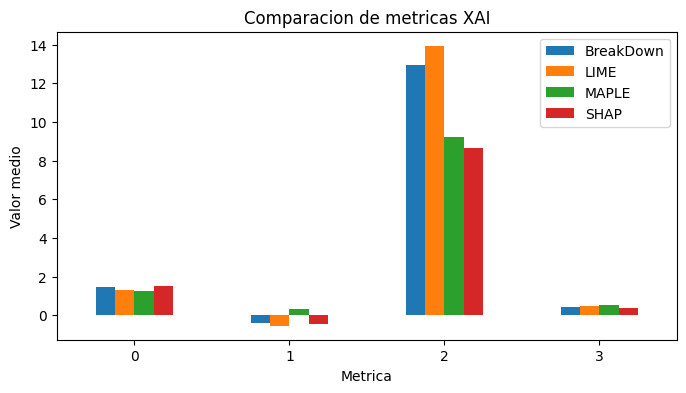

In [7]:
ax = comparison.plot.bar(figsize=(8, 4))
ax.set_title("Comparacion de metricas XAI")
ax.set_xlabel("Metrica")
ax.set_ylabel("Valor medio")
ax.tick_params(axis="x", rotation=0)